In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression ,LogisticRegression,ridge_regression
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('ford.csv.xls')

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.isna().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [6]:
df['fuelType'].unique()

array(['Petrol', 'Diesel', 'Hybrid', 'Electric', 'Other'], dtype=object)

In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first',sparse_output= False)
encoded = encoder.fit_transform(df[['fuelType']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

df = pd.concat([df.drop('fuelType', axis=1), encoded_df], axis=1)

In [8]:
df.head()

,model,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,Fiesta,2017,12000,Automatic,15944,150,57.7,1.0,0.0,0.0,0.0,1.0
1,Focus,2018,14000,Manual,9083,150,57.7,1.0,0.0,0.0,0.0,1.0
2,Focus,2017,13000,Manual,12456,150,57.7,1.0,0.0,0.0,0.0,1.0
3,Fiesta,2019,17500,Manual,10460,145,40.3,1.5,0.0,0.0,0.0,1.0
4,Fiesta,2019,16500,Automatic,1482,145,48.7,1.0,0.0,0.0,0.0,1.0


In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [10]:
df['transmission'] = le.fit_transform(df['transmission'])
df['model'] = le.fit_transform(df['model'])

In [11]:
df.head()

,model,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,5,2017,12000,0,15944,150,57.7,1.0,0.0,0.0,0.0,1.0
1,6,2018,14000,1,9083,150,57.7,1.0,0.0,0.0,0.0,1.0
2,6,2017,13000,1,12456,150,57.7,1.0,0.0,0.0,0.0,1.0
3,5,2019,17500,1,10460,145,40.3,1.5,0.0,0.0,0.0,1.0
4,5,2019,16500,0,1482,145,48.7,1.0,0.0,0.0,0.0,1.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              17966 non-null  int64  
 1   year               17966 non-null  int64  
 2   price              17966 non-null  int64  
 3   transmission       17966 non-null  int64  
 4   mileage            17966 non-null  int64  
 5   tax                17966 non-null  int64  
 6   mpg                17966 non-null  float64
 7   engineSize         17966 non-null  float64
 8   fuelType_Electric  17966 non-null  float64
 9   fuelType_Hybrid    17966 non-null  float64
 10  fuelType_Other     17966 non-null  float64
 11  fuelType_Petrol    17966 non-null  float64
dtypes: float64(6), int64(6)
memory usage: 1.6 MB


<Axes: ylabel='price'>

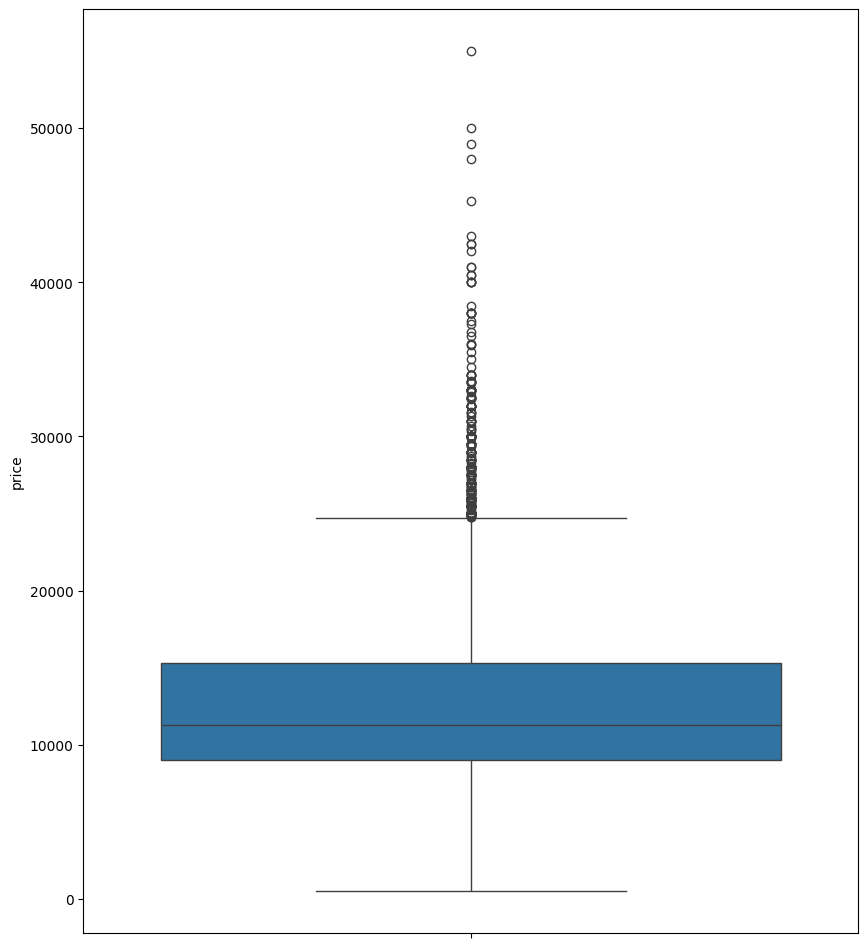

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12))

sns.boxplot(data=df ,y ='price')

In [14]:
def Outlier(df):
   col = list(df.columns)
   for i in col:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    print(f"Lower limit  {lower_bound}")
    upper_bound=Q3+1.5*IQR
    print(f"Upper limit  {upper_bound}")

    df = df[(df[i] >= lower_bound) & (df[i] <= upper_bound)]
   return df

In [15]:
df = Outlier(df)

Lower limit  0.5
Upper limit  12.5
Lower limit  2013.0
Upper limit  2021.0
Lower limit  1489.0
Upper limit  21505.0
Lower limit  1.0
Upper limit  1.0
Lower limit  -18685.0
Upper limit  58099.0
Lower limit  -142.5
Upper limit  317.5
Lower limit  37.19999999999999
Upper limit  82.80000000000001
Lower limit  0.7000000000000001
Upper limit  1.5
Lower limit  0.0
Upper limit  0.0
Lower limit  0.0
Upper limit  0.0
Lower limit  0.0
Upper limit  0.0
Lower limit  1.0
Upper limit  1.0


In [16]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'tax', 'mpg',
       'engineSize', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol'],
      dtype='object')

In [17]:
x = df.drop('price',axis = 1)
y = df['price']

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,test_size=0.3,random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scl =   StandardScaler()
x_test = scl.fit_transform(x_test)

x_train = scl.fit_transform(x_train)

In [20]:
from sklearn.linear_model import LinearRegression

regmodel = LinearRegression()
regmodel.fit(x_train,y_train)

LinearRegression()

In [21]:
x_test = scl.fit_transform(x_test)
y_pred=regmodel.predict(x_test)


from sklearn.metrics import r2_score
reg_accuracy=r2_score(y_test,y_pred)
reg_accuracy

0.6937742197445371

In [22]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()

ridge_model.fit(x_train,y_train)

Ridge()

In [23]:

y_pred=ridge_model.predict(x_test)

#to get accuracy score
from sklearn.metrics import r2_score
ridge_accuracy=r2_score(y_test,y_pred)
ridge_accuracy

0.6937719671007154

In [24]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()

lasso_model.fit(x_train,y_train)

Lasso()

In [25]:

y_pred=lasso_model.predict(x_test)

#to get accuracy score
from sklearn.metrics import r2_score
lasso_accuracy=r2_score(y_test,y_pred)
lasso_accuracy

0.6937660565550896

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_features = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False is often used because LinearRegression will add an intercept by default
X_poly = poly_features.fit_transform(x)

In [27]:
from sklearn.model_selection import train_test_split
p_train,p_test,q_train,q_test=train_test_split(X_poly,y,train_size=0.7,test_size=0.3,random_state=42)

In [28]:
poly_model = LinearRegression()
poly_model.fit(p_train,q_train)

LinearRegression()

In [29]:

q_pred=poly_model.predict(p_test)

#to get accuracy score
from sklearn.metrics import r2_score
poly_accuracy=r2_score(q_test,q_pred)
poly_accuracy

0.8541208702424493

In [30]:
print(f"**************************\n Accuracuy Score : \n Linear Model : {reg_accuracy}\n Ridge : {ridge_accuracy}\nLasso : {lasso_accuracy}\n Polynominal : {poly_accuracy}*************************")

**************************
 Accuracuy Score : 
 Linear Model : 0.6937742197445371
 Ridge : 0.6937719671007154
Lasso : 0.6937660565550896
 Polynominal : 0.8541208702424493*************************


In [31]:
models = {
    "reg_model": regmodel,
    "lasso_model": lasso_model,
    "ridge_model": ridge_model,
    "poly_model": poly_model
}

accuracy = {
    "reg_model": reg_accuracy,
    "lasso_model": lasso_accuracy,
    "ridge_model": ridge_accuracy,
    "poly_model": poly_accuracy
}

best_model_name = max(accuracy, key=accuracy.get)

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: poly_model


In [32]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)